In [179]:
from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parent))

In [180]:
%reload_ext autoreload
%autoreload 2



import numpy as np
from numpy.linalg import norm, inv
import matplotlib.pyplot as plt
import importlib
import measurements.state_to_edgepoints as state_to_edgepoints_module
from trajectory.Constants import G

state_to_edgepoints_module = importlib.reload(state_to_edgepoints_module)

In [181]:

from filters import ChristianRobinson 



from datetime import datetime
from dataclasses import dataclass
import pytz
from enum import Enum

from utils import circle_points, camera_view, noise
from classes import Camera, Body, PlanetImage, Pose

from filters import SatEKF


from measurements.InterfaceWrapperFuncs import Set_camera, gen_traj, plot_traj, get_images,run_step, get_T_c_p, plot_est_dist_xyz, plot_est_dist_xyz_errors, plot_trajs

In [182]:
# === SYSTEM PARAMETERS ===
MOON_RADIUS_KM = 1737.4
MOON_MU = 4902.8  # km3/s2
CAMERA_FOCAL_LENGTH_MM = 2500  # mm (example, adjust as needed)
CAMERA_PIXEL_SIZE_UM = 5.5  # um
CAMERA_RESOLUTION = (2048, 2048)  # pixels

# === FILTER TUNING ===
Q_POS_VARIANCE = 1.0  # km2
Q_VEL_VARIANCE = 0.0001  # km2/s2
R_MEAS_VARIANCE = 1000  # km2

# === TIME ===
TRAJECTORY_DT = 1000  # seconds
N_STEPS = 50

# === FRAME CONVENTIONS ===
# - Planet frame (P): Moon-centered inertial
# - Camera frame (C): Spacecraft-centered, +Z toward nadir
# - T_p_c: Rotation matrix from planet to camera frame

In [183]:
f, mu, n_pixels = Set_camera()  # Sagitta camera parameters

# One-time calculation
camera = Camera(f, mu, n_pixels)
camera.calc_specs()
moon_radius = MOON_RADIUS_KM  # km
moon_mu = MOON_MU  # km3/s2

body = Body(a=moon_radius, b=moon_radius, c=moon_radius)
print(body)

w, h = 1280, 720  # Camera resolution
# Camera calibration matrix K (focal length in pixels, principal point at center)
K = np.array([
    [1120.0, 0.0, w / 2.0],
    [0.0, 1120.0, h / 2.0],
    [0.0, 0.0, 1.0],
], dtype=np.float64)

k_inv = np.linalg.inv(K)

camera_spec_ellie = {
    "K": K,
    "width": w,
    "height": h,
}

camera_spec_ellie2 = {
    "K": np.linalg.inv(camera.K_inv),
    "width": camera.resolution[0],
    "height": camera.resolution[1],
}

cr_alg = ChristianRobinson(k_inv, body.a, body.b, body.c)

Worldview:
 - Ellipsoid semi-axes a,b,c = [1737.4, 1737.4, 1737.4] km



Orbital period (T): 45980.8058633618s


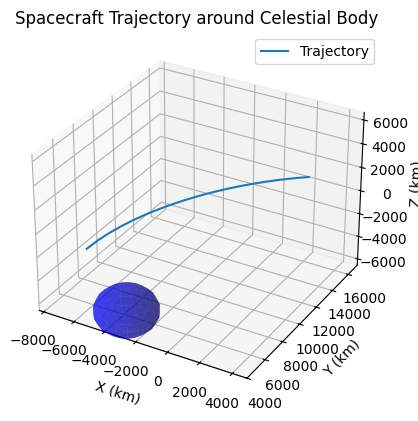

24
0


In [184]:
pos = np.array([-5000, 4000, 100])
r = np.linalg.norm(pos)
v = np.sqrt( moon_mu / r) + 0.2 # km/s, slightly
State0 = [pos[0], pos[1], pos[2], 0, v, 0] 



dt = 1000
op, body_struct = gen_traj(Starting_state=State0, dt=dt)
plot_traj(op.states, body_struct)

print(len(op.states))
print(op.ts[0])


In [185]:
# for 10 points along traj gen images and test CR alg
cam_offset = np.array([0, 0, 0]) # no offset for now
images, edges, outs, states, times = get_images(op.states, op.ts, body_struct, cam_offset, camera_spec_ellie, 10)


State at t=0.0s: [-5000.     4000.      100.        0.        1.075     0.   ]
State at t=1000.0s: [-4957.789  5038.336    99.156     0.08      1.002    -0.002]
State at t=2000.0s: [-4846.148  6006.823    96.923     0.14      0.935    -0.003]
State at t=3000.0s: [-4682.419  6911.242    93.648     0.185     0.874    -0.004]
State at t=4000.0s: [-4478.956  7757.374    89.579     0.22      0.819    -0.004]
State at t=5000.0s: [-4244.75   8550.536    84.895     0.247     0.768    -0.005]
State at t=6000.0s: [-3986.487  9295.454    79.73      0.268     0.722    -0.005]
State at t=7000.0s: [-3709.236  9996.276    74.185     0.285     0.68     -0.006]
State at t=8000.0s: [-3416.91  10656.621    68.338     0.299     0.641    -0.006]
State at t=9000.0s: [-3112.578 11279.649    62.252     0.309     0.605    -0.006]


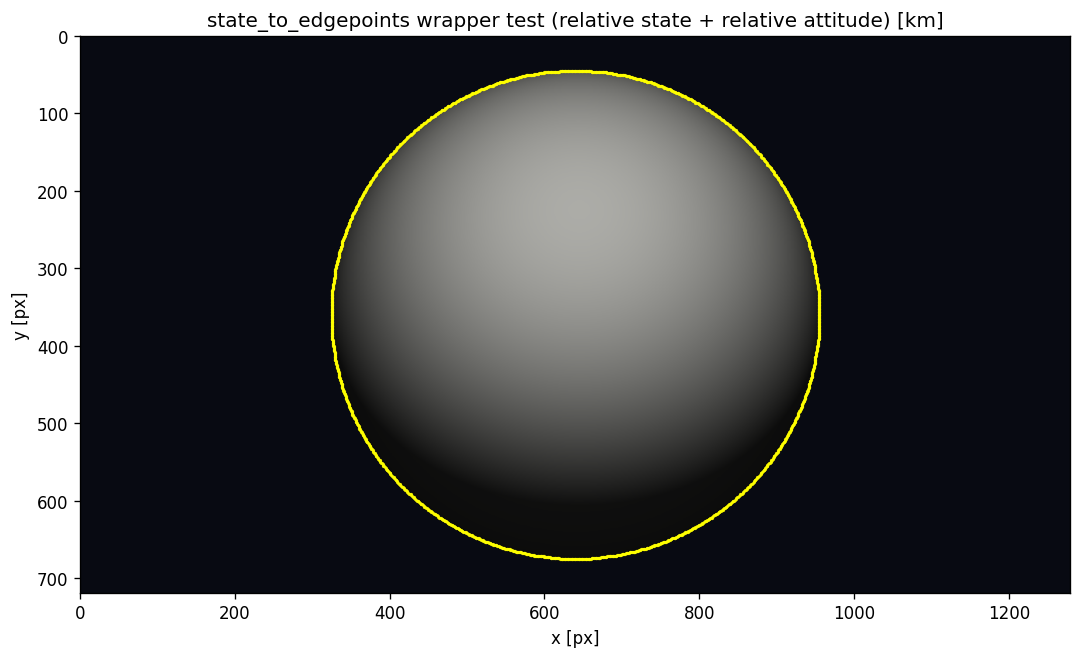

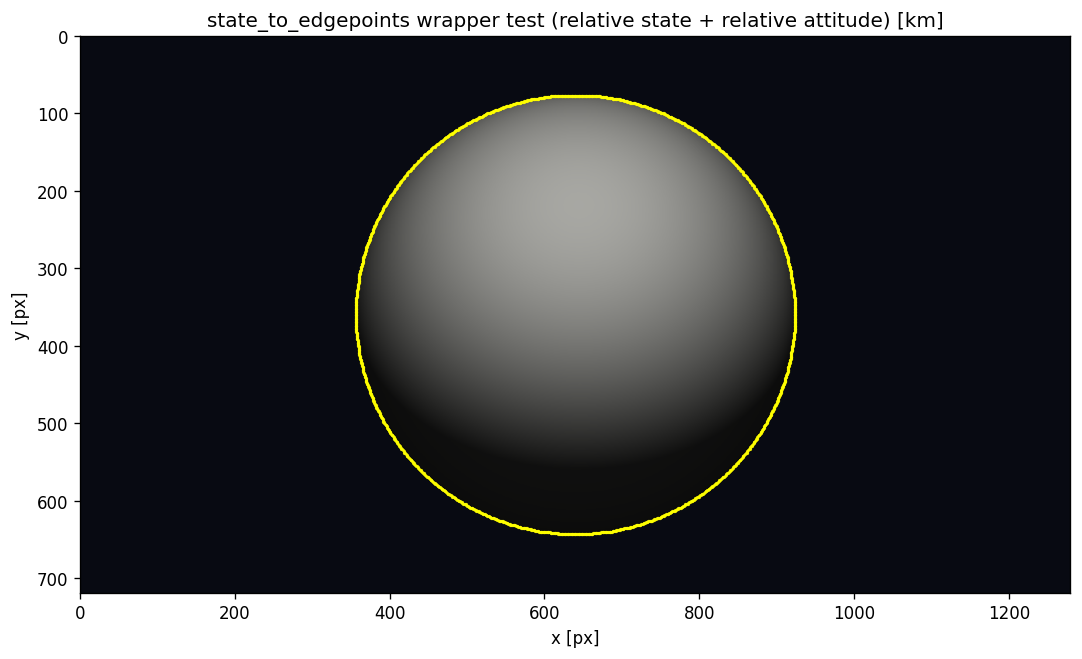

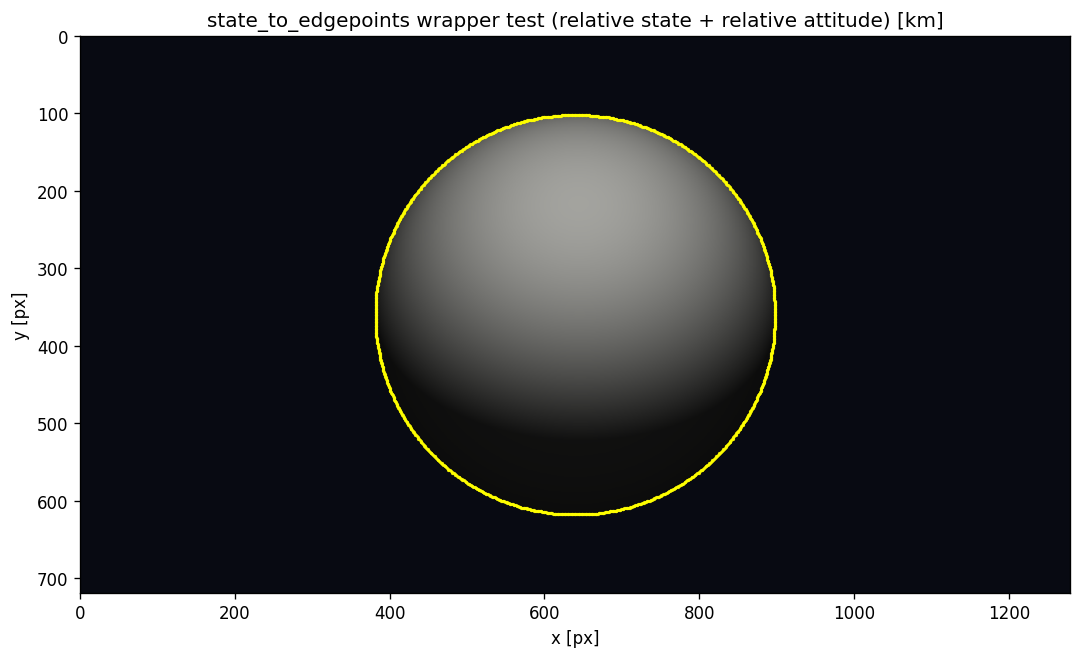

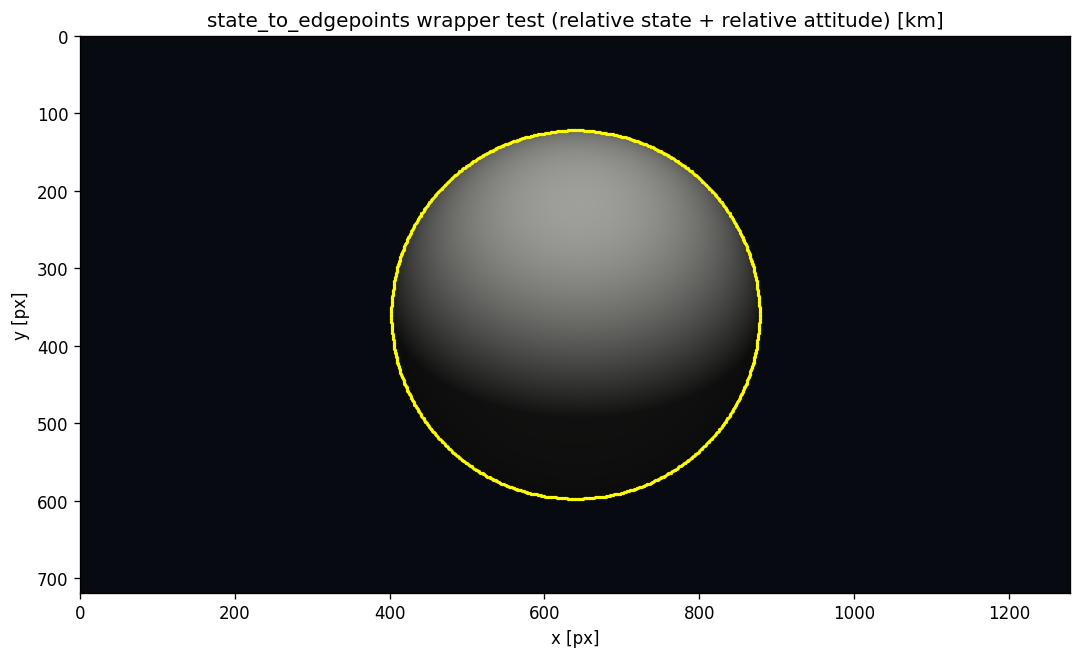

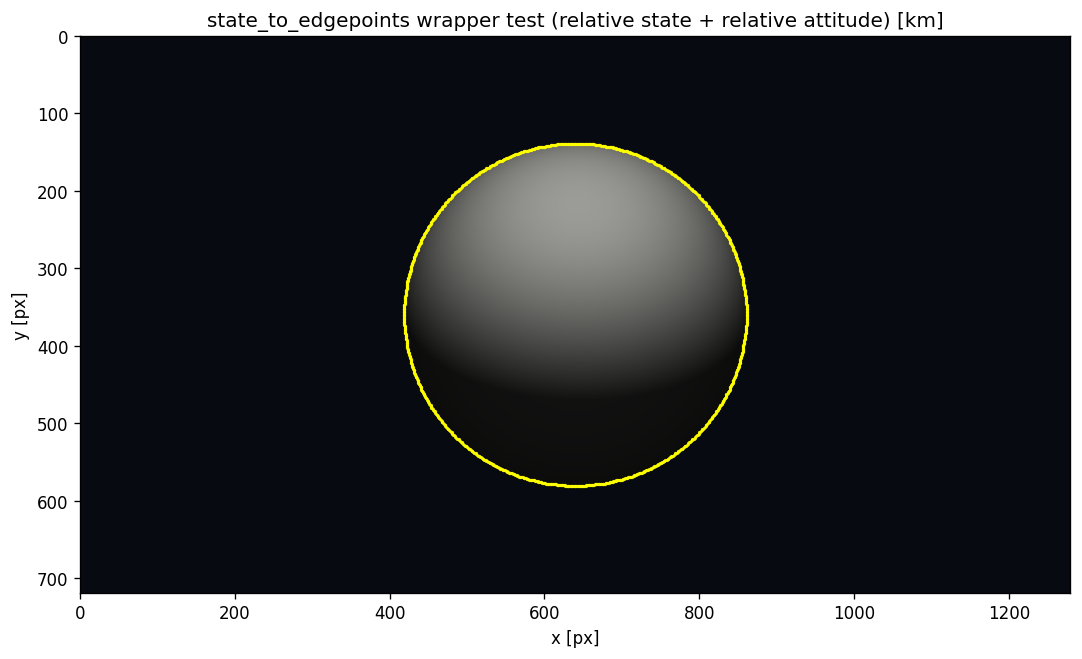

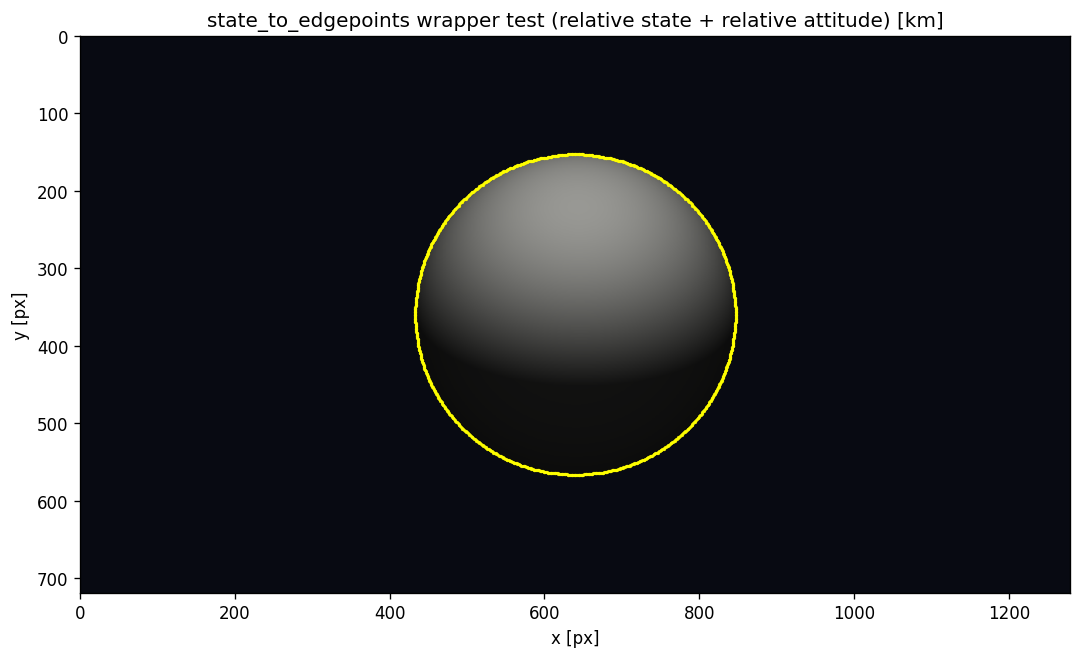

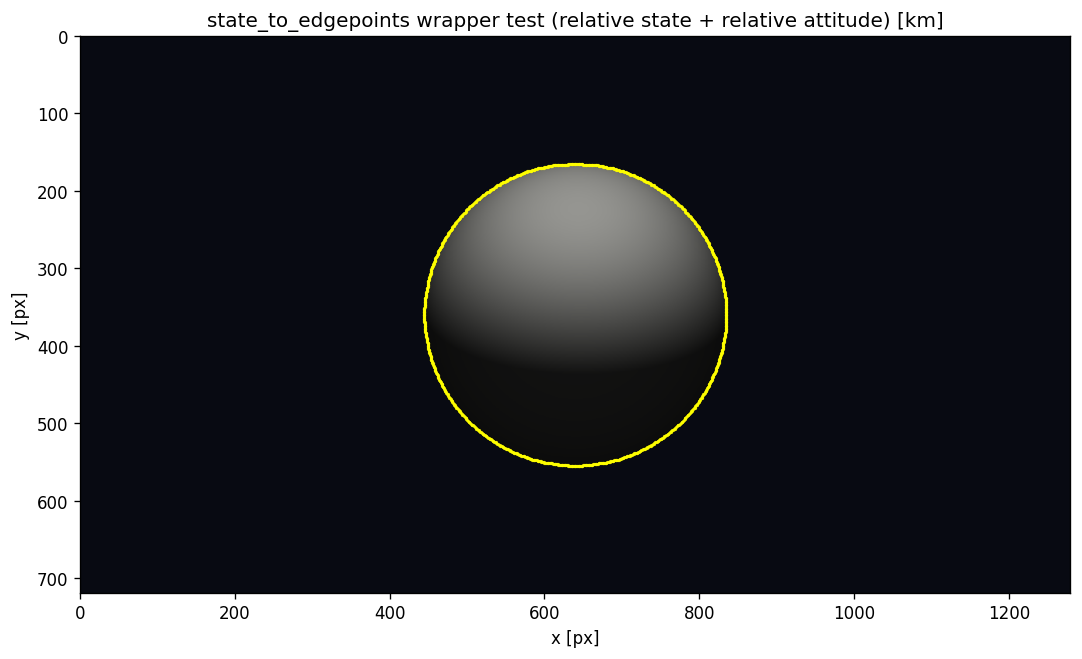

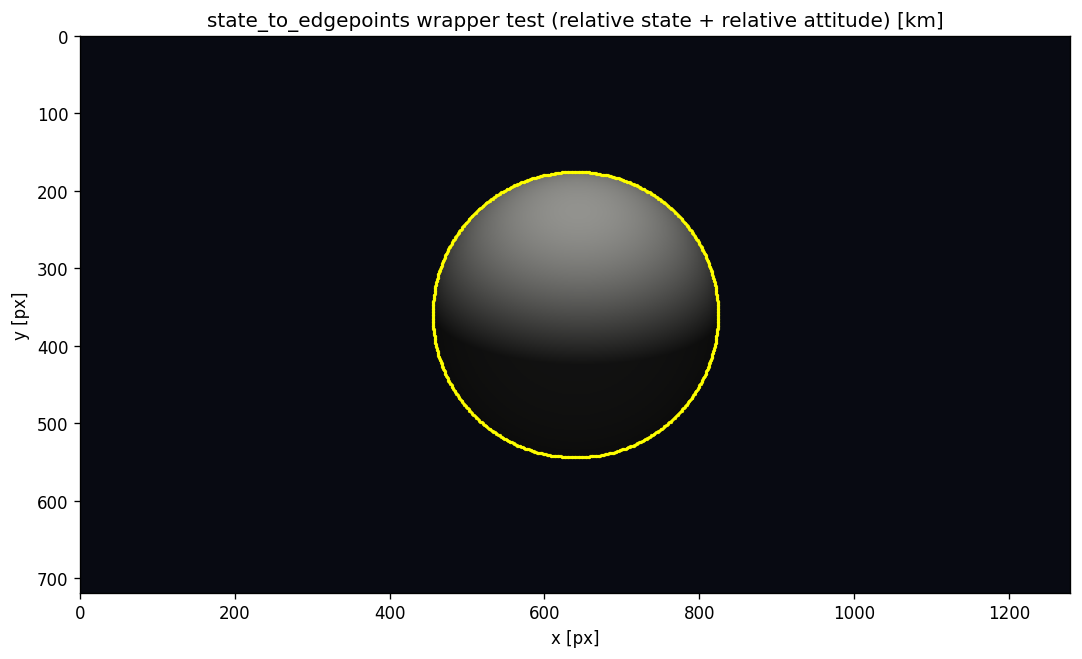

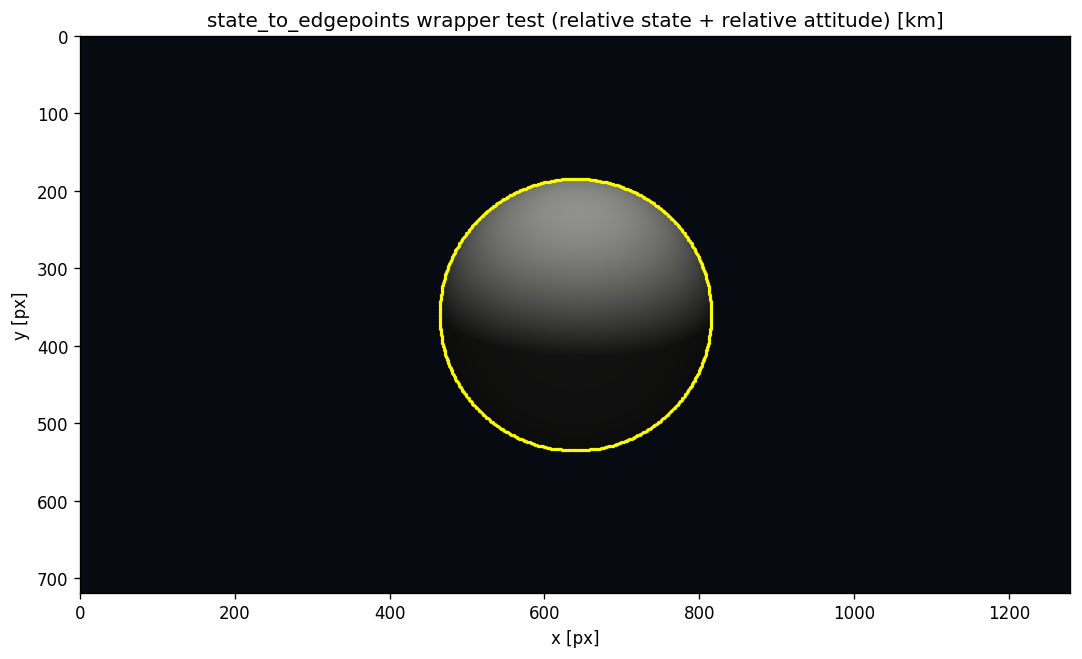

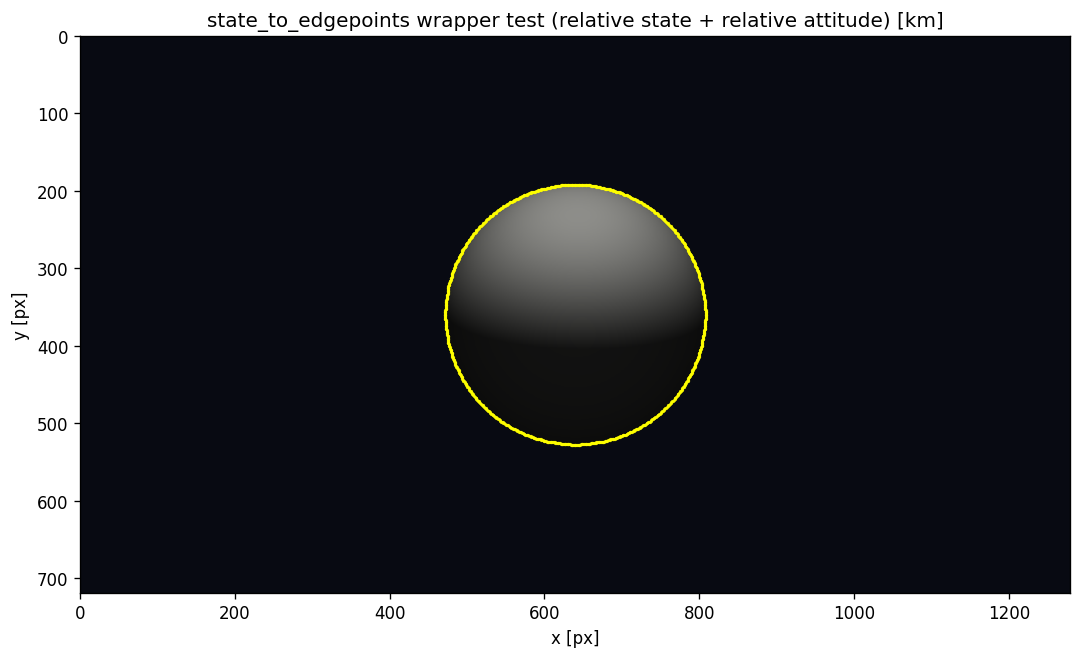

In [186]:

i = 0
for out in outs:
    i += 1
    if i % 1 == 0:
        w, h = camera_spec_ellie["width"], camera_spec_ellie["height"]
        state_to_edgepoints_module.plot_edge_points(
            out,
            w,
            h,
            x_limits=None,
            y_limits=None,
        )

In [ ]:

# Test CR Algorithm on Reference Trajectory
# Note: Camera offset is now handled in get_images() via attitude_offset_from_center_pointing
rho_p_est = []  # Will store satellite position vector (planet frame)
for i in range(len(outs)):
    print(f"Running CR alg on image {i+1}/{len(outs)}")
    out = outs[i]
    state = states[i]
    edge = edges[i]
    
    # Compute camera-to-planet rotation matrix T_c_p from render output
    T_c_p = get_T_c_p(out)  # T_c_p: camera to planet frame rotation
    
    # Prepare edge points as homogeneous coordinates [x, y, 1]
    edge_homogeneous = np.hstack((edge, np.ones((edge.shape[0], 1))))

    # Run Christian-Robinson: returns camera->planet vector in camera frame (rc_est) 
    # and planet frame (rp_est)
    rc_est, rp_est = run_step(edge_homogeneous, state[0:3], T_c_p, print_stats=True, cr_alg=cr_alg)
    # Negate rp_est to get satellite position in planet frame (consistent with orientation of truth positions)
    rho_p_est.append(-rp_est)

Running CR alg on image 1/10
Calc Position:
 - (C->P in camera frame): [  -0.     -0.   6413.39] (6413.39 km)
 - (C->P in planet frame): [ 5007.4  -4005.92  -100.15] (6413.39 km)
Actual position:
 - (C->P in camera frame): [  -0.     -0.   6403.91] (6403.91 km)
 - (C->P in planet frame): [ 5000. -4000.  -100.] (6403.91 km)
Est Error - Actual:
 - (Camera frame): [-0.   -0.    9.48] (9.48 km)
 - (Planet frame): [ 7.4  -5.92 -0.15] (9.48 km)
Distance error: 9.48 km (0.148060%)
Angular error: 0.0000 degrees
Running CR alg on image 2/10
Calc Position:
 - (C->P in camera frame): [   0.      0.   7081.89] (7081.89 km)
 - (C->P in planet frame): [ 4966.66 -5047.35   -99.33] (7081.89 km)
Actual position:
 - (C->P in camera frame): [   0.     -0.   7069.25] (7069.25 km)
 - (C->P in planet frame): [ 4957.79 -5038.34   -99.16] (7069.25 km)
Est Error - Actual:
 - (Camera frame): [ 0.    0.   12.64] (12.64 km)
 - (Planet frame): [ 8.87 -9.01 -0.18] (12.64 km)
Distance error: 12.64 km (0.178826%)
Ang

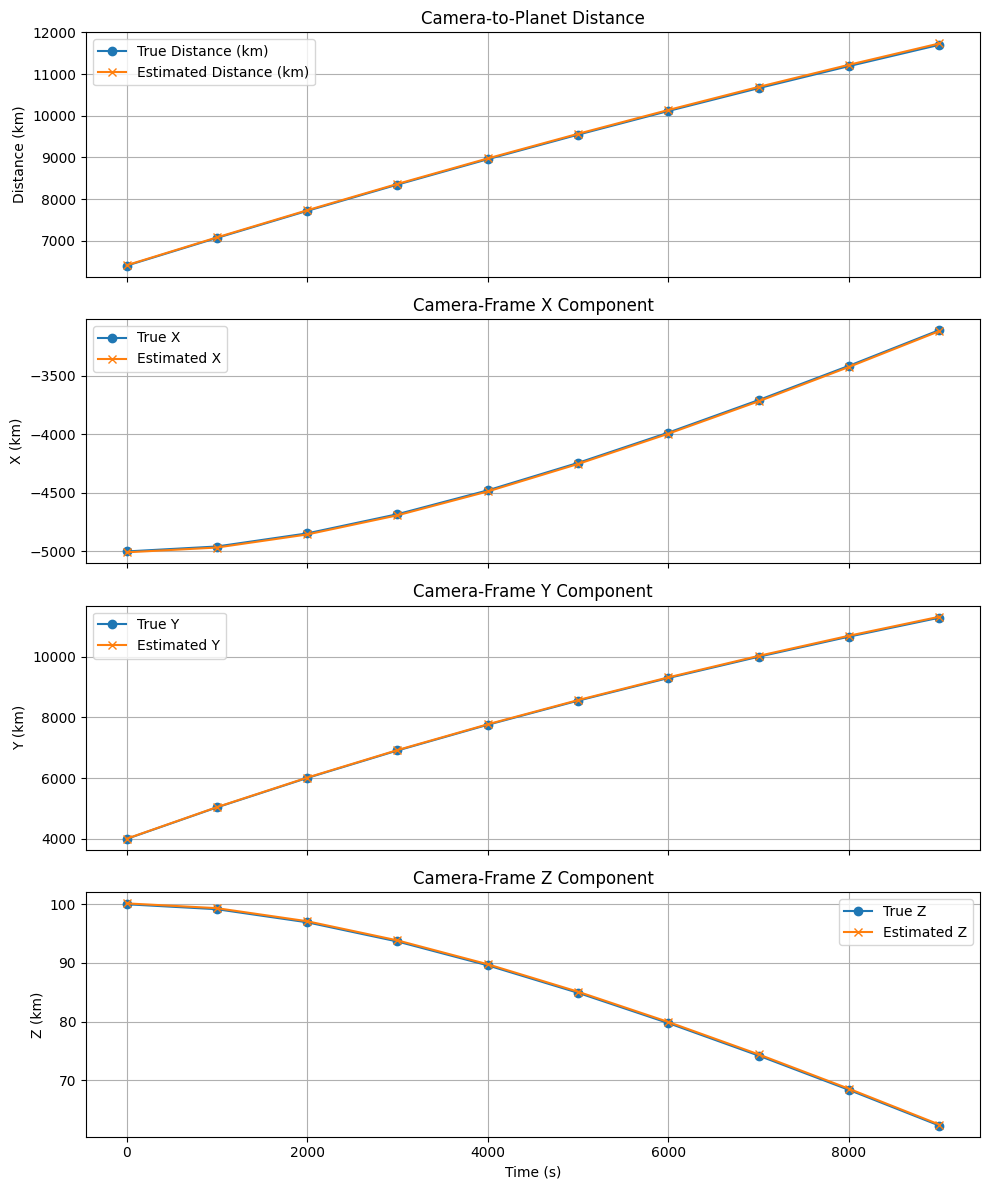

In [188]:
# compare true/estimated camera-frame vectors and distances with optional axis limits
states = np.array(states)
pos = states[:, 0:3]
rho_p_est = np.array(rho_p_est)
times = np.array(times)

#print(np.shape(pos))
#print(estimates[:, 1])
#print("times:", times)

# plt.plot()


plot_est_dist_xyz(
    times,
    pos,
    rho_p_est,
    
)

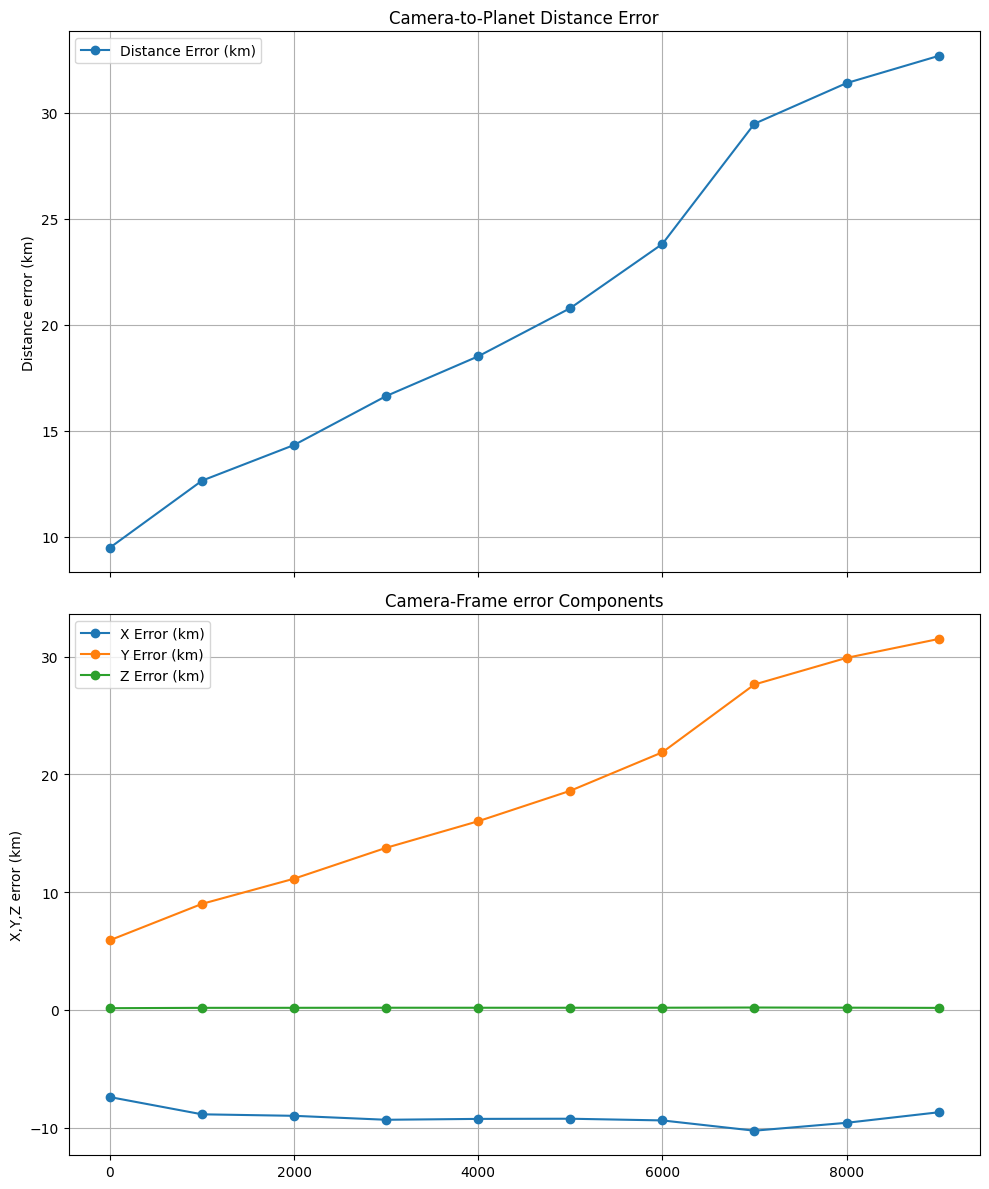

In [189]:
plot_est_dist_xyz_errors(
    times,
    pos,
    rho_p_est,
)

In [190]:
# EKF Configuration
Q = np.diag([Q_POS_VARIANCE, Q_POS_VARIANCE, Q_POS_VARIANCE, 
             Q_VEL_VARIANCE, Q_VEL_VARIANCE, Q_VEL_VARIANCE])  # Process noise covariance

Q_perfect = np.zeros((6, 6))  # Perfect process model (no noise)

R = np.diag([R_MEAS_VARIANCE, R_MEAS_VARIANCE, R_MEAS_VARIANCE])  # Measurement noise covariance

dt = TRAJECTORY_DT  # Time step in seconds
N = N_STEPS

state_0 = np.array(State0)
mu0 = state_0
sigma0 = np.diag([1.0, 1.0, 1.0, 0.0001, 0.0001, 0.0001])  # Initial state covariance

central_body_mass = MOON_MU / G  # kg, derived from MOON_MU / G

ekf = SatEKF(Q, R, dt, mu0, sigma0, central_body_mass)

state_0=array([-5000.   ,  4000.   ,   100.   ,     0.   ,     1.075,     0.   ])


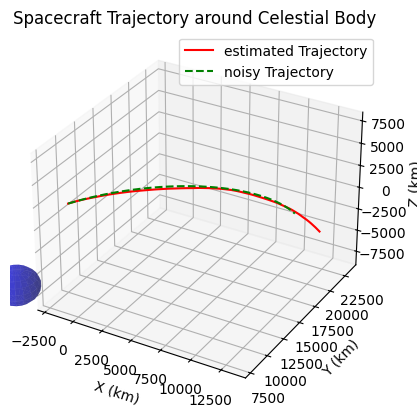

In [191]:
print(f"{state_0=}")
states_perfect = []
states_noisy = []

state_clean = state
state_noisy = state + noise(Q)

t = 0

# get noisy trajectory for EKF testing
for i in range(N):
    states_perfect.append(state_clean)
    states_noisy.append(state_noisy)
    
    # Perfect trajectory (for comparison)
    state_next_clean = ekf.f_func(state_clean) 

    # Noisy/realistic trajectory
    process_noise = noise(Q)
    state_next_noisy = ekf.f_func(state_noisy) + process_noise

    t += dt
    states_perfect.append(state_next_clean)
    states_noisy.append(state_next_noisy)

    state_noisy = state_next_noisy
    state_clean = state_next_clean 

states_noisy = np.array(states_noisy)
states_perfect = np.array(states_perfect)

ts = np.arange(0, N) * dt # Stops *just* before N*dt though so maybe we do N+1?

plot_trajs(states_noisy, states_perfect, body_struct)

In [192]:
# get CR estimates for EKF measurement updates
print(ts[i])
print(states_noisy[i])
cam_offset = np.array([0, 0, 0]) # no offset for now
images, edges, outs, states, times = get_images(states_noisy, ts, body_struct, cam_offset, camera_spec_ellie, N)


49000
[ 6098.13  19627.766  -368.384     0.39      0.084    -0.01 ]
State at t=0.0s: [-3114.046 11280.326    62.871     0.33      0.624    -0.002]
State at t=1000.0s: [-2781.183 11887.74     59.602     0.344     0.587    -0.023]
State at t=2000.0s: [-2781.183 11887.74     59.602     0.344     0.587    -0.023]
State at t=3000.0s: [-2432.419 12459.207    37.57      0.361     0.55     -0.026]
State at t=4000.0s: [-2432.419 12459.207    37.57      0.361     0.55     -0.026]
State at t=5000.0s: [-2069.643 12994.025    10.583     0.359     0.527    -0.026]
State at t=6000.0s: [-2069.643 12994.025    10.583     0.359     0.527    -0.026]
State at t=7000.0s: [-1710.334 13507.178   -15.725     0.353     0.481    -0.02 ]
State at t=8000.0s: [-1710.334 13507.178   -15.725     0.353     0.481    -0.02 ]
State at t=9000.0s: [-1355.261 13974.385   -35.459     0.331     0.446    -0.035]
State at t=10000.0s: [-1355.261 13974.385   -35.459     0.331     0.446    -0.035]
State at t=11000.0s: [-1024.055 

In [193]:
# Generate Measurements from Noisy Trajectory
rp_est_CR = []  # CR estimates in planet frame
rc_est_CR = []  # CR measurements in camera frame
planet_to_camera_rotations = []  # T_c_p matrices for each timestep
for i in range(len(outs)):
    print(f"Running CR alg on image {i+1}/{len(outs)}")
    out = outs[i]
    state = states[i]
    edge = edges[i]
    
    # Compute camera-to-planet rotation matrix T_c_p from render output
    T_c_p = get_T_c_p(out)
    planet_to_camera_rotations.append(T_c_p)
    
    # Prepare edge points as homogeneous coordinates [x, y, 1]
    edge_homogeneous = np.hstack((edge, np.ones((edge.shape[0], 1))))

    # Run Christian-Robinson: returns camera->planet vector in camera frame (rc_est) 
    # and planet location in planet frame (rp_est)
    rc_est, rp_est = run_step(edge_homogeneous, state[0:3], T_c_p, print_stats=True, cr_alg=cr_alg)
    rp_est_CR.append(rp_est)
    rc_est_CR.append(rc_est)

Running CR alg on image 1/50
Calc Position:
 - (C->P in camera frame): [    0.      -0.   11735.56] (11735.56 km)
 - (C->P in planet frame): [  3122.86 -11312.26    -63.05] (11735.56 km)
Actual position:
 - (C->P in camera frame): [   -0.       0.   11702.43] (11702.43 km)
 - (C->P in planet frame): [  3114.05 -11280.33    -62.87] (11702.43 km)
Est Error - Actual:
 - (Camera frame): [ 0.   -0.   33.13] (33.13 km)
 - (Planet frame): [  8.82 -31.93  -0.18] (33.13 km)
Distance error: 33.13 km (0.283085%)
Angular error: 0.0000 degrees
Running CR alg on image 2/50
Calc Position:
 - (C->P in camera frame): [    0.       0.   12249.62] (12249.62 km)
 - (C->P in planet frame): [  2790.46 -11927.4     -59.8 ] (12249.62 km)
Actual position:
 - (C->P in camera frame): [   -0.       0.   12208.89] (12208.89 km)
 - (C->P in planet frame): [  2781.18 -11887.74    -59.6 ] (12208.89 km)
Est Error - Actual:
 - (Camera frame): [ 0.    0.   40.74] (40.74 km)
 - (Planet frame): [  9.28 -39.67  -0.2 ] (40.

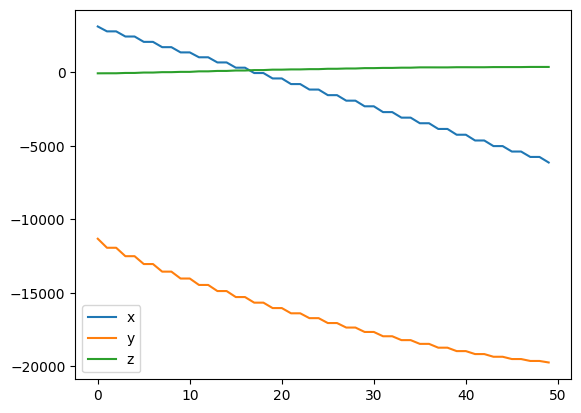

In [194]:
# Plot CR estimates in planet frame
plt.plot(rp_est_CR)
plt.legend(["x", "y", "z"])

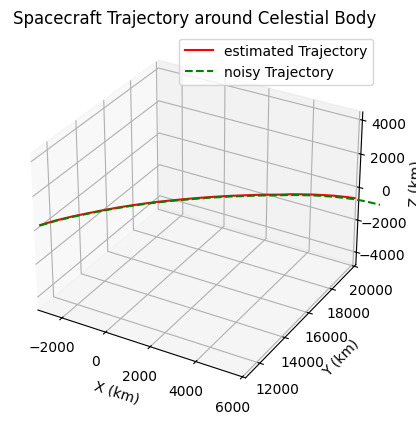

In [195]:
rp_est_CR = np.array(rp_est_CR)

plot_trajs(-rp_est_CR, states_noisy, body_struct)

In [196]:
# EKF Estimation Loop
mus = []  # EKF state estimates over time
sigmas = []  # EKF covariances over time
for i in range(N):
    print(f"EKF step {i+1}/{N}")
    ekf.predict()
    measurement = -rc_est_CR[i]  # Negate for measurement model
    print("Measurement:", measurement)
    print("Predicted state:", ekf.mu)
    ekf.update(measurement, planet_to_camera_rotations[i])
    mus.append(ekf.mu)
    sigmas.append(ekf.sigma)

print("Final EKF state estimate:", ekf.mu)

EKF step 1/50
Measurement: [    -0.         0.    -11735.563]
Predicted state: [-4953.329  5037.646    99.067     0.093     1.       -0.002]
Measurement function output: [    0.939  3434.813 -6174.562]
EKF step 2/50
Measurement: [    -0.        -0.    -12249.622]
Predicted state: [-4495.514  7153.796    90.018     0.318     1.501    -0.006]
Measurement function output: [    6.32   2748.128 -7990.138]
EKF step 3/50
Measurement: [    -0.        -0.    -12249.622]
Predicted state: [-3314.738 11067.571    68.422     0.657     2.371    -0.012]
Measurement function output: [     2.613    706.462 -11531.878]
EKF step 4/50
Measurement: [     0.        -0.    -12736.205]
Predicted state: [-2288.617 14029.608    49.988     0.779     2.528    -0.014]
Measurement function output: [   -14.637   -441.876 -14208.262]
EKF step 5/50
Measurement: [     0.        -0.    -12736.205]
Predicted state: [-1614.86  15386.035    26.22      0.754     2.171    -0.017]
Measurement function output: [    -1.278  -13

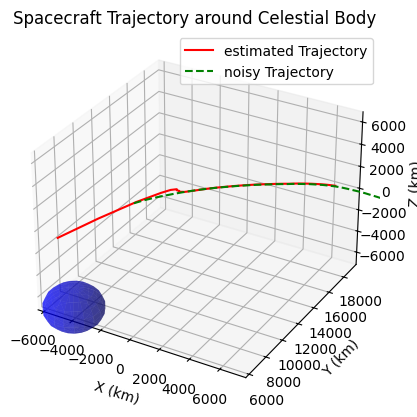

In [197]:
mus = np.array(mus)
sigmas = np.array(sigmas)
plot_trajs(mus, states_noisy, body_struct)


Final EKF state estimate: [ 6057.855 19702.468  -371.509     0.194     0.042    -0.002]


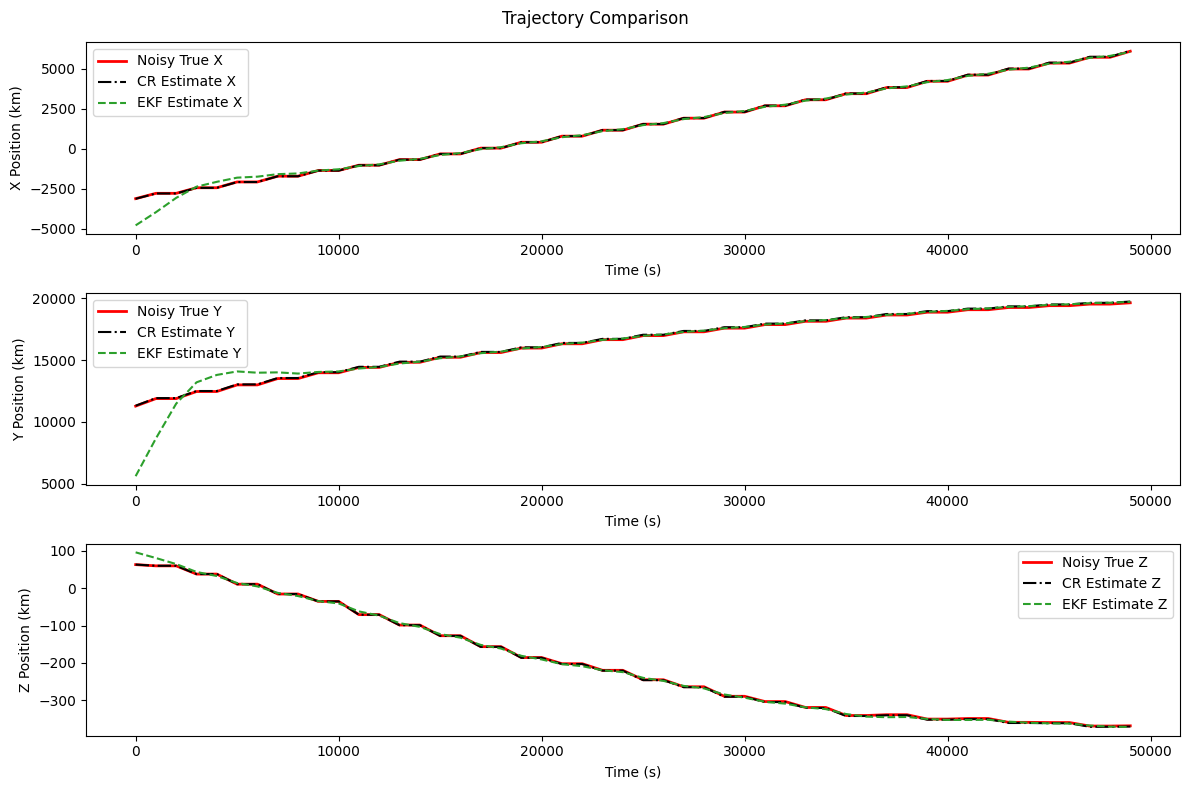

In [198]:
# plot EKF estimates vs true trajectory and CR estimates vs time
mus = np.array(mus)
states_noisy = np.array(states_noisy)
    

plt.figure(figsize=(12, 8))
plt.suptitle("Trajectory Comparison")
plt.subplot(3, 1, 1)
print("Final EKF state estimate:", ekf.mu)
# Align array lengths with ts (mus and states_noisy are length 51, ts is 50)
mus = mus[:len(ts)]
states_noisy = states_noisy[:len(ts)]
plt.plot(ts, states_noisy[:, 0], label='Noisy True X', color='red', linewidth=2)
plt.plot(ts, -rp_est_CR[:, 0], label='CR Estimate X', color='k', linestyle='-.')
plt.plot(ts, mus[:, 0], label='EKF Estimate X', color='tab:green', linestyle='--')
# plt.plot(ts, states_perfect[:, 0], label='Perfect True X', color='blue', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('X Position (km)')
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(ts, states_noisy[:, 1], label='Noisy True Y', color='red', linewidth=2)
plt.plot(ts, -rp_est_CR[:, 1], label='CR Estimate Y', color='k', linestyle='-.')
plt.plot(ts, mus[:, 1], label='EKF Estimate Y', color='tab:green', linestyle='--')
# plt.plot(ts, states_perfect[:, 1], label='Perfect True Y', color='blue', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Y Position (km)')
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(ts, states_noisy[:, 2], label='Noisy True Z', color='red', linewidth=2)
plt.plot(ts, -rp_est_CR[:, 2], label='CR Estimate Z', color='k', linestyle='-.')
plt.plot(ts, mus[:, 2], label='EKF Estimate Z', color='tab:green', linestyle='--')
# plt.plot(ts, states_perfect[:, 2], label='Perfect True Z', color='blue', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Z Position (km)')
plt.legend()
plt.tight_layout()
plt.show()

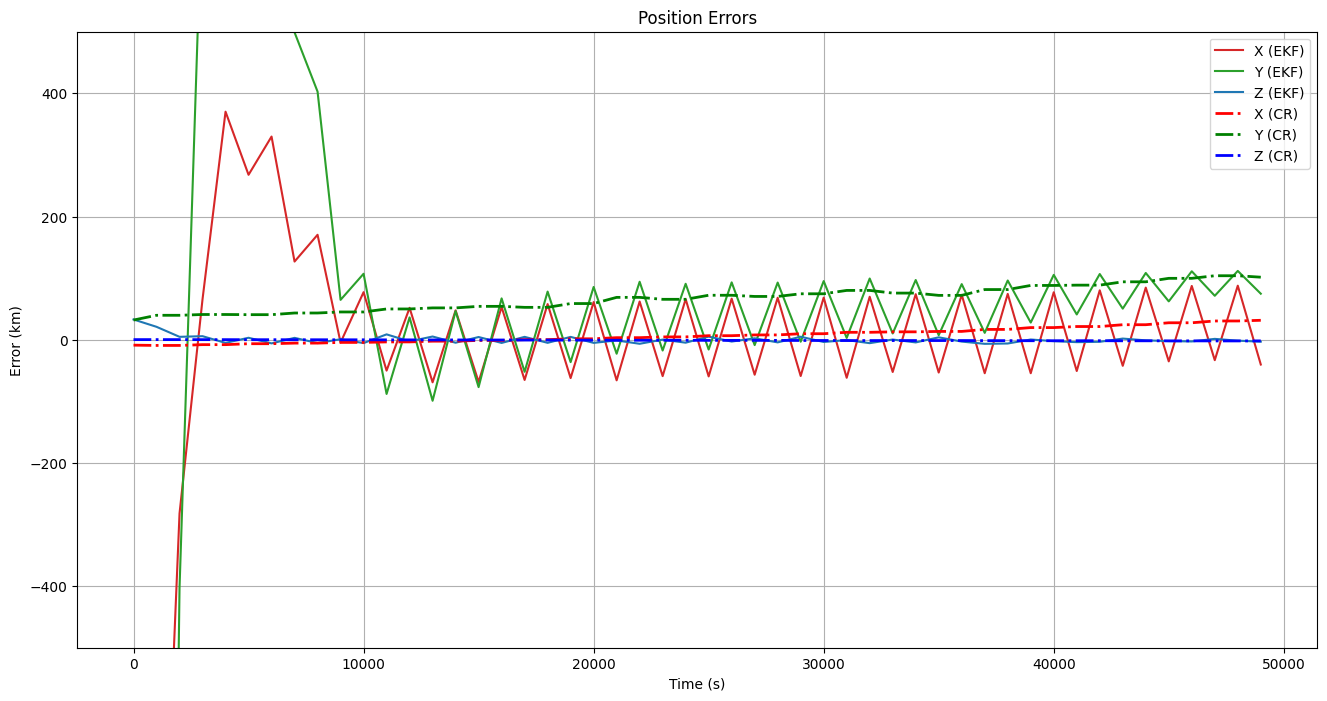

In [199]:
EKF_err = mus - states_noisy
CR_err = (-rp_est_CR) - states_noisy[:,:3]



plt.figure(figsize=(16, 8))


# plt.subplot(2, 1, 1)
plt.title("Position Errors")
plt.plot(ts, EKF_err[:,0], label='X (EKF)', color="tab:red")
plt.plot(ts, EKF_err[:,1], label='Y (EKF)', color="tab:green")
plt.plot(ts, EKF_err[:,2], label='Z (EKF)', color="tab:blue")
plt.plot(ts, CR_err[:,0], "-.", label='X (CR)', color="red", linewidth=2)
plt.plot(ts, CR_err[:,1], "-.", label='Y (CR)', color="green", linewidth=2)
plt.plot(ts, CR_err[:,2], "-.", label='Z (CR)', color="blue", linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Error (km)')
plt.ylim(-500, 500)
plt.grid(True)
plt.legend()
plt.show()


# # plt.subplot(2, 1, 2)
# plt.title("Velocity Errors")
# plt.plot(ts, EKF_err[:,3], label='X (EKF)')
# plt.plot(ts, EKF_err[:,4], label='Y (EKF)')
# plt.plot(ts, EKF_err[:,5], label='Z (EKF)')
# plt.plot(ts, CR_err[:,0], "-.", label='X (CR)')
# plt.plot(ts, CR_err[:,1], "-.", label='Y (CR)')
# plt.plot(ts, CR_err[:,2], "-.", label='Z (CR)')
# plt.xlabel('Time (s)')
# plt.ylabel('Error (km/s)')
# plt.legend()
# plt.grid(True)

# plt.tight_layout()
plt.show()



In [200]:
rp_est_CR_norm = np.apply_along_axis(np.linalg.norm, 1, rp_est_CR[:,:3])
rp_est_EKF_norm = np.apply_along_axis(np.linalg.norm, 1, mus[:,:3])

state_norm_perfect = np.apply_along_axis(np.linalg.norm, 1, states_perfect[:,:3])
state_norm_noisy = np.apply_along_axis(np.linalg.norm, 1, states_noisy[:,:3])

EKF State 0 Error: [-14.27 -48.38   0.28  -0.     0.01  -0.  ]


<Figure size 1000x600 with 0 Axes>

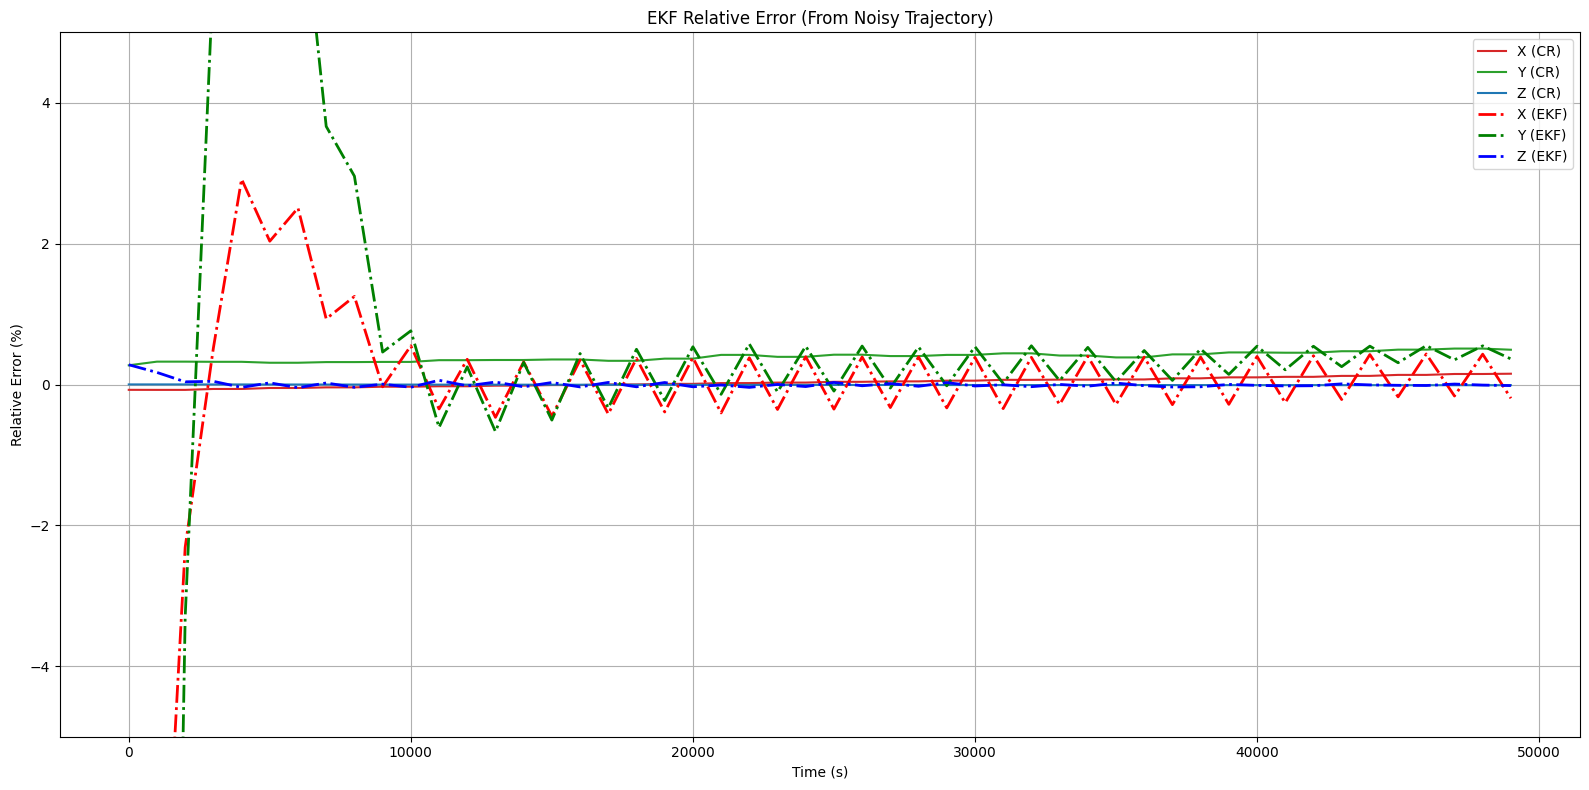

CR State 0 Error: [-0.075  0.273  0.002]
CR State 0 Error: 0.28308501829139576
EKF State 0 Error: [-14.27  -48.383   0.281]
EKF State 0 Error: 50.443909896259925
CR State -1 Error: [ 0.153  0.494 -0.009]
CR State -1 Error: 0.5171947667278142
EKF State -1 Error: [-0.196  0.363 -0.015]
EKF State -1 Error: 0.41313250449534167


In [201]:
CR_err_rel = 100*CR_err / state_norm_noisy[:,None]
EKF_err_rel = 100*EKF_err / state_norm_noisy[:,None]

np.set_printoptions(precision=3, suppress=True)



print(f"EKF State 0 Error: {np.round(EKF_err_rel[0], 2)}")

plt.figure(figsize=(10, 6))

plt.figure(figsize=(16, 8))
plt.title("EKF Relative Error (From Noisy Trajectory)")
plt.plot(ts, CR_err_rel[:,0], label='X (CR)', color="tab:red")
plt.plot(ts, CR_err_rel[:,1], label='Y (CR)', color="tab:green")
plt.plot(ts, CR_err_rel[:,2], label='Z (CR)', color="tab:blue")
plt.plot(ts, EKF_err_rel[:,0], "-.", label='X (EKF)', color="red", linewidth=2)
plt.plot(ts, EKF_err_rel[:,1], "-.", label='Y (EKF)', color="green", linewidth=2)
plt.plot(ts, EKF_err_rel[:,2], "-.", label='Z (EKF)', color="blue", linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Relative Error (%)')
plt.legend()
plt.ylim(-5, 5)
plt.grid(True)

plt.tight_layout()
plt.show()

CR_0 = CR_err_rel[0]
EKF_0 = EKF_err_rel[0, :3]

print(f"CR State 0 Error: {CR_0}")
print(f"CR State 0 Error: {norm(CR_0)}")
print(f"EKF State 0 Error: {EKF_0}")
print(f"EKF State 0 Error: {norm(EKF_0)}")

CR_0 = CR_err_rel[-1]
EKF_0 = EKF_err_rel[-1, :3]

print(f"CR State -1 Error: {CR_0}")
print(f"CR State -1 Error: {norm(CR_0)}")
print(f"EKF State -1 Error: {EKF_0}")
print(f"EKF State -1 Error: {norm(EKF_0)}")

## Monte carlo-ish

In [204]:
# Monte Carlo Simulation: Generate multiple trajectories, run CR and EKF, collect statistics
N_TRAJECTORIES = 10  # Number of Monte Carlo runs

# Storage for errors
CR_errors_all = []  # List of CR position errors over time for each trajectory
EKF_errors_all = []  # List of EKF position errors over time for each trajectory

for traj_idx in range(N_TRAJECTORIES):
    print(f"Trajectory {traj_idx + 1}/{N_TRAJECTORIES}")
    
    # Generate noisy trajectory (similar to earlier cell)
    states_perfect = []
    states_noisy = []
    state_clean = np.array(State0)
    state_noisy = state_clean + noise(Q)
    
    for i in range(N):
        states_perfect.append(state_clean)
        states_noisy.append(state_noisy)
        
        state_next_clean = ekf.f_func(state_clean)
        process_noise = noise(Q)
        state_next_noisy = ekf.f_func(state_noisy) + process_noise
        
        state_noisy = state_next_noisy
        state_clean = state_next_clean
    
    states_noisy = np.array(states_noisy)
    states_perfect = np.array(states_perfect)
    
    # Generate images and CR estimates
    cam_offset = np.array([0, 0, 0])
    images, edges, outs, states_meas, times = get_images(states_noisy, ts, body_struct, cam_offset, camera_spec_ellie, N)
    
    rp_est_CR = []
    rc_est_CR = []
    planet_to_camera_rotations = []
    for i in range(len(outs)):
        out = outs[i]
        state = states_meas[i]
        edge = edges[i]
        
        T_c_p = get_T_c_p(out)
        planet_to_camera_rotations.append(T_c_p)
        
        edge_homogeneous = np.hstack((edge, np.ones((edge.shape[0], 1))))
        rc_est, rp_est = run_step(edge_homogeneous, state[0:3], T_c_p, print_stats=False, cr_alg=cr_alg)
        rp_est_CR.append(rp_est)
        rc_est_CR.append(rc_est)
    
    rp_est_CR = np.array(rp_est_CR)
    
    # Run EKF
    ekf_mc = SatEKF(Q, R, dt, np.array(State0), sigma0, central_body_mass)  # Fresh EKF for each trajectory
    mus = []
    for i in range(N):
        ekf_mc.predict()
        measurement = -rc_est_CR[i]
        ekf_mc.update(measurement, planet_to_camera_rotations[i])
        mus.append(ekf_mc.mu)
    mus = np.array(mus)
    
    # Compute errors
    CR_err = (-rp_est_CR) - states_noisy[:len(rp_est_CR), :3]  # CR position error
    EKF_err = mus - states_noisy[:len(mus), :]  # EKF full state error
    
    CR_errors_all.append(CR_err)
    EKF_errors_all.append(EKF_err[:, :3])  # Only position for comparison

# Convert to arrays for statistics
CR_errors_all = np.array(CR_errors_all)  # Shape: (N_TRAJECTORIES, N, 3)
EKF_errors_all = np.array(EKF_errors_all)  # Shape: (N_TRAJECTORIES, N, 3)

# Compute statistics over trajectories
CR_mean_error = np.mean(CR_errors_all, axis=0)  # Mean error over time
CR_std_error = np.std(CR_errors_all, axis=0)     # Std dev over time
EKF_mean_error = np.mean(EKF_errors_all, axis=0)
EKF_std_error = np.std(EKF_errors_all, axis=0)

print("Statistics computed. Plotting...")

Trajectory 1/10
State at t=0.0s: [-5000.096  3999.86     98.923     0.01      1.066    -0.01 ]
State at t=1000.0s: [-4941.063  5027.82     87.049     0.103     0.995    -0.007]
State at t=2000.0s: [-4804.428  5988.786    81.233     0.175     0.91     -0.005]
State at t=3000.0s: [-4603.145  6866.049    76.575     0.23      0.839    -0.025]
State at t=4000.0s: [-4354.223  7672.352    51.236     0.263     0.792    -0.027]
State at t=5000.0s: [-4077.062  8437.486    23.708     0.297     0.725    -0.03 ]
State at t=6000.0s: [-3768.306  9138.34     -7.102     0.324     0.671    -0.018]
State at t=7000.0s: [-3435.755  9786.405   -26.853     0.333     0.606    -0.005]
State at t=8000.0s: [-3095.082 10369.272   -34.098     0.362     0.554    -0.002]
State at t=9000.0s: [-2727.36  10903.888   -37.644     0.379     0.527    -0.011]
State at t=10000.0s: [-2342.108 11411.324   -47.616     0.386     0.5       0.012]
State at t=11000.0s: [-1953.265 11891.623   -36.494     0.386     0.445     0.02 ]
S

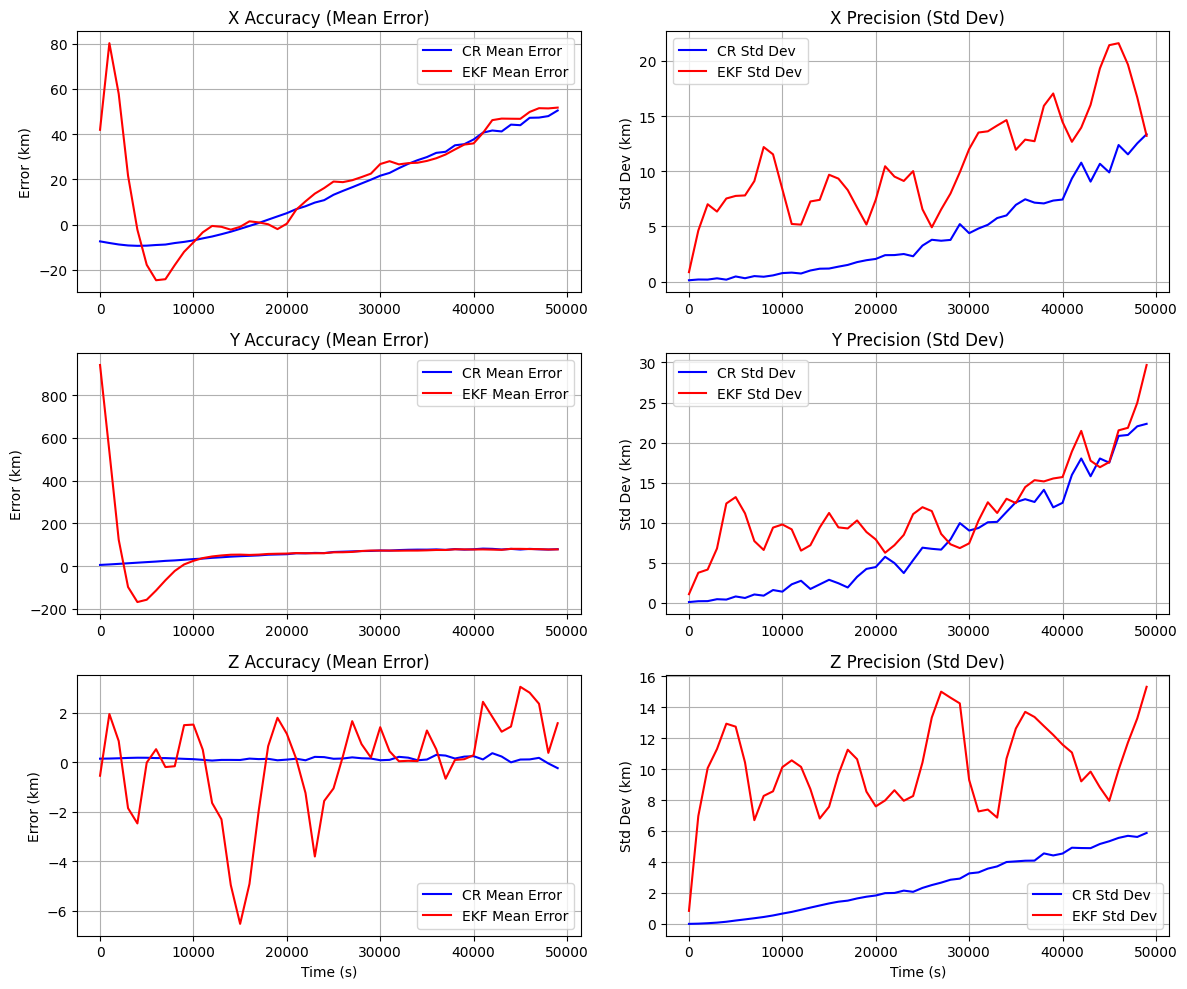

Final Step (t=49000s) Statistics:
CR Mean Error: [50.445 79.582 -0.234] km
CR Std Dev: [13.363 22.343  5.873] km
EKF Mean Error: [51.721 78.847  1.581] km
EKF Std Dev: [13.216 29.683 15.308] km


In [205]:
# Plot accuracy (mean error) and precision (std dev) for CR and EKF
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
components = ['X', 'Y', 'Z']

for i in range(3):
    # Accuracy: Mean error
    axes[i, 0].plot(ts[:len(CR_mean_error)], CR_mean_error[:, i], label='CR Mean Error', color='blue')
    axes[i, 0].plot(ts[:len(EKF_mean_error)], EKF_mean_error[:, i], label='EKF Mean Error', color='red')
    axes[i, 0].set_title(f'{components[i]} Accuracy (Mean Error)')
    axes[i, 0].set_ylabel('Error (km)')
    axes[i, 0].legend()
    axes[i, 0].grid(True)
    
    # Precision: Std dev
    axes[i, 1].plot(ts[:len(CR_std_error)], CR_std_error[:, i], label='CR Std Dev', color='blue')
    axes[i, 1].plot(ts[:len(EKF_std_error)], EKF_std_error[:, i], label='EKF Std Dev', color='red')
    axes[i, 1].set_title(f'{components[i]} Precision (Std Dev)')
    axes[i, 1].set_ylabel('Std Dev (km)')
    axes[i, 1].legend()
    axes[i, 1].grid(True)

axes[-1, 0].set_xlabel('Time (s)')
axes[-1, 1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

# Print final statistics
print("Final Step (t=49000s) Statistics:")
print(f"CR Mean Error: {CR_mean_error[-1]} km")
print(f"CR Std Dev: {CR_std_error[-1]} km")
print(f"EKF Mean Error: {EKF_mean_error[-1]} km")
print(f"EKF Std Dev: {EKF_std_error[-1]} km")